In [3]:
#importing all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#import dataset
df = pd.read_csv('/content/soccer_ball.csv')
df.shape

/tmp/ipykernel_1221/981104330.py:2: DtypeWarning: Columns (78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/soccer_ball.csv')


(17125, 107)

In [5]:
df.head()

,ID,Name,Age,OVA,Nationality,Club,BOV,BP,Position,Player Photo,...,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,GK,Gender
0,2,G. Pasquale,33,69,Italy,Udinese,71,LWB,LM,https://cdn.sofifa.com/players/000/002/16_120.png,...,70+-1,70+-1,71+-2,70+-1,69+0,69+0,69+0,70+-1,17+0,Male
1,16,Luis García,37,71,Spain,KAS Eupen,70,CM,CM CAM CDM,https://cdn.sofifa.com/players/000/016/19_120.png,...,66+1,66+1,62+1,60+1,60+1,60+1,60+1,60+1,17+1,Male
2,27,J. Cole,33,71,England,Coventry City,71,CAM,CAM RM RW LM,https://cdn.sofifa.com/players/000/027/16_120.png,...,54+0,54+0,52+0,47+0,46+0,46+0,46+0,47+0,15+0,Male
3,36,D. Yorke,36,68,Trinidad &amp; Tobago,Sunderland,70,ST,NaN,https://cdn.sofifa.com/players/000/036/09_120.png,...,65+0,65+0,56+0,57+0,51+0,51+0,51+0,57+0,22+0,Male
4,41,Iniesta,36,81,Spain,Vissel Kobe,82,CAM,CM CAM,https://cdn.sofifa.com/players/000/041/20_120.png,...,73+3,73+3,70+3,67+3,64+3,64+3,64+3,67+3,17+3,Male


In [19]:
df.isnull().sum()/len(df)*100



In [6]:
#funtions for height and weight and values

def clean_money_column(value):
    """
    Converts strings like '€1.1M', '€500K', '€0'
    into float numbers like 1100000, 500000, 0
    """
    if pd.isna(value):
        return 0.0

    value = str(value).strip()
    value = value.replace('€', '')

    if value.endswith('M'):
        return float(value[:-1]) * 1_000_000

    elif value.endswith('K'):
        return float(value[:-1]) * 1_000

    else:
        return float(value)

def clean_height(value):
    """
    Converts height to centimeters
    e.g. "6'2" → 188cm  OR  "188cm" → 188
    """
    value = str(value).strip()

    # Format 1: feet and inches like 6'2"
    if "'" in value:
        parts = value.replace('"', '').split("'")
        feet  = int(parts[0])
        inches = int(parts[1])
        return round((feet * 12 + inches) * 2.54, 1)

    # Format 2: already in cm like "188cm"
    elif 'cm' in value:
        return float(value.replace('cm', ''))

    else:
        return float(value)


def clean_weight(value):
    """
    Converts weight to kilograms
    e.g. "170lbs" → 77kg  OR  "77kg" → 77
    """
    value = str(value).strip()

    # Format 1: pounds like "170lbs"
    if 'lbs' in value:
        return round(float(value.replace('lbs', '')) * 0.453592, 1)

    # Format 2: already in kg like "77kg"
    elif 'kg' in value:
        return float(value.replace('kg', ''))

    else:
        return float(value)

In [7]:
# Check 1 - Standard missing value check
print(df.isnull().sum())

# Check 2 - Look at value and wage columns
print(df['Value'].head(10))
print(df['Wage'].head(10))

# Check 3 - Check data types
print(df.dtypes)

ID             0
Name           0
Age            0
OVA            0
Nationality    0
              ..
CB             0
RCB            0
RB             0
GK             0
Gender         0
Length: 107, dtype: int64
0    €625K
1    €600K
2    €1.1M
3       €0
4    €5.5M
5    €725K
6    €2.8M
7      €1K
8       €0
9    €400K
Name: Value, dtype: object
0     €7K
1     €7K
2    €15K
3      €0
4    €12K
5     €5K
6    €44K
7    €60K
8      €0
9    €40K
Name: Wage, dtype: object
ID              int64
Name           object
Age             int64
OVA             int64
Nationality    object
                ...  
CB             object
RCB            object
RB             object
GK             object
Gender         object
Length: 107, dtype: object


In [8]:
# Your function is like a machine
# .apply() feeds every row through that machine

df['Value_clean'] = df['Value'].apply(clean_money_column)
df['Wage_clean'] = df['Wage'].apply(clean_money_column)

print(df[['Value', 'Value_clean', 'Wage', 'Wage_clean']].head(10))
print(df['Value_clean'].dtype)

   Value  Value_clean  Wage  Wage_clean
0  €625K     625000.0   €7K      7000.0
1  €600K     600000.0   €7K      7000.0
2  €1.1M    1100000.0  €15K     15000.0
3     €0          0.0    €0         0.0
4  €5.5M    5500000.0  €12K     12000.0
5  €725K     725000.0   €5K      5000.0
6  €2.8M    2800000.0  €44K     44000.0
7    €1K       1000.0  €60K     60000.0
8     €0          0.0    €0         0.0
9  €400K     400000.0  €40K     40000.0
float64


In [9]:
df['height_cm'] = df['Height'].apply(clean_height)
df['weight_kg'] = df['Weight'].apply(clean_weight)

print(df[['Height', 'height_cm', 'Weight', 'weight_kg']].head(10))


  Height  height_cm  Weight  weight_kg
0   6'0"      182.9  181lbs       82.1
1  5'10"      177.8  143lbs       64.9
2   5'9"      175.3  161lbs       73.0
3  5'11"      180.3  165lbs       74.8
4   5'7"      170.2  150lbs       68.0
5   5'8"      172.7  163lbs       73.9
6   5'7"      170.2  159lbs       72.1
7  5'10"      177.8  157lbs       71.2
8  5'10"      177.8  174lbs       78.9
9   5'7"      170.2  157lbs       71.2


In [10]:
# Replace 0.0 with NaN so it doesn't skew our averages
df['Value_clean'] = df['Value_clean'].replace(0.0, np.nan)
df['Wage_clean']  = df['Wage_clean'].replace(0.0, np.nan)

# Verify how many zeros we converted to NaN
print(df['Value_clean'].isnull().sum())
print(df['Wage_clean'].isnull().sum())

457
423


In [11]:
print(df['Value_clean'].mean(skipna=True))
print(df['Wage_clean'].mean(skipna=True))

2637769.0184785216
10799.688660040714


/tmp/ipykernel_1221/2992920080.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='OVA',


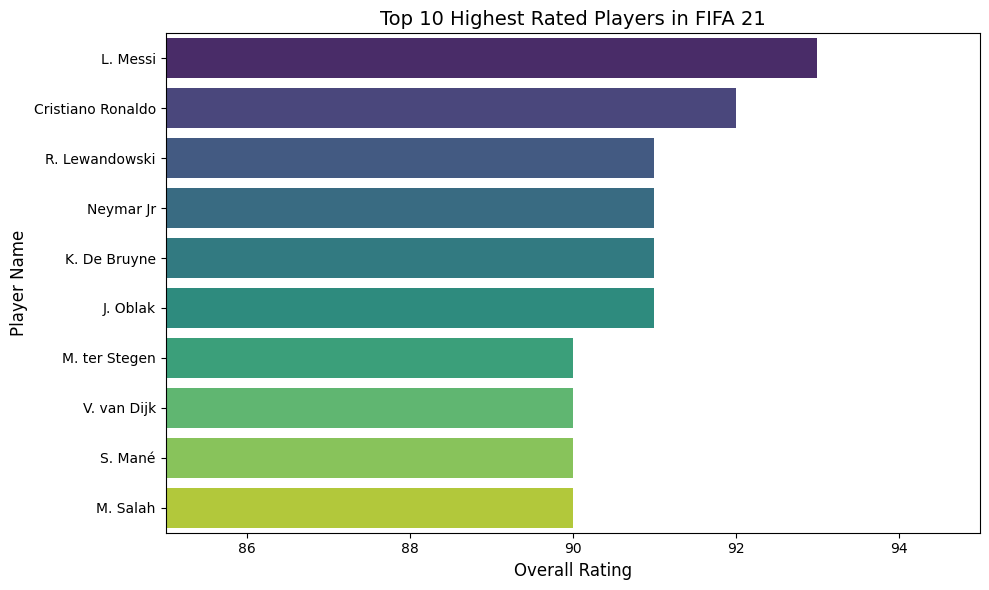

In [12]:
# Get top 10 players
top_10_players = df.nlargest(10, 'OVA')[['Name', 'OVA']]

# Create the chart
plt.figure(figsize=(10, 6))

sns.barplot(x='OVA',
            y='Name',
            data=top_10_players,
            palette='viridis')

plt.title("Top 10 Highest Rated Players in FIFA 21", fontsize=14)
plt.xlabel("Overall Rating", fontsize=12)
plt.ylabel("Player Name", fontsize=12)
plt.xlim(85, 95)   # zoom into the meaningful range

plt.tight_layout()
plt.show()

/tmp/ipykernel_1221/577296286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nationalities.values, y=top_nationalities.index, palette='coolwarm')


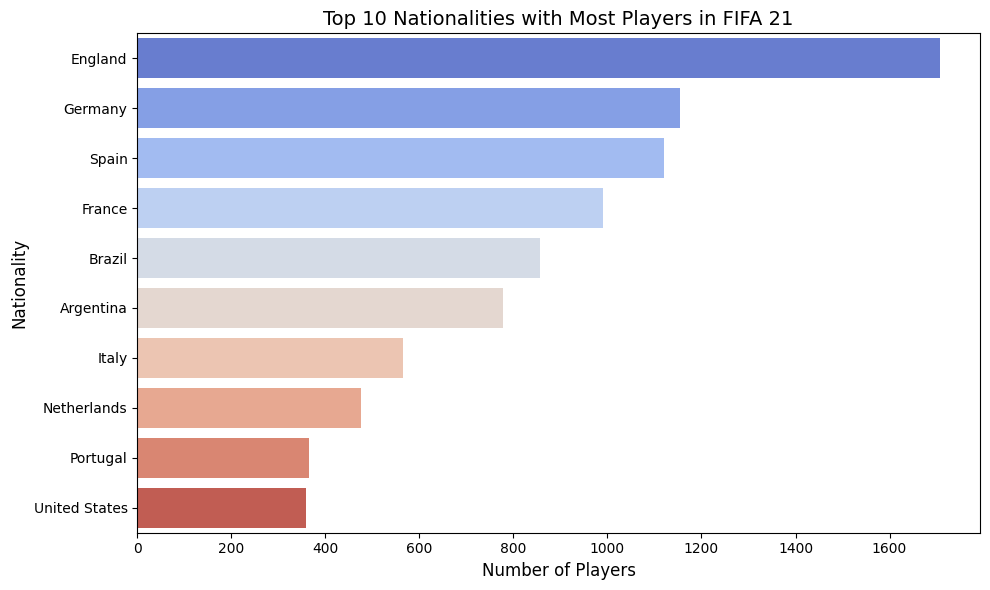

In [13]:
# Get top 10 nationalities
top_nationalities = df['Nationality'].value_counts().head(10)

# Create the chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_nationalities.values, y=top_nationalities.index, palette='coolwarm')

plt.title("Top 10 Nationalities with Most Players in FIFA 21", fontsize=14)
plt.xlabel("Number of Players", fontsize=12)
plt.ylabel("Nationality", fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1221/2359688553.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paying_clubs.values, y=top_paying_clubs.index, palette='rocket')


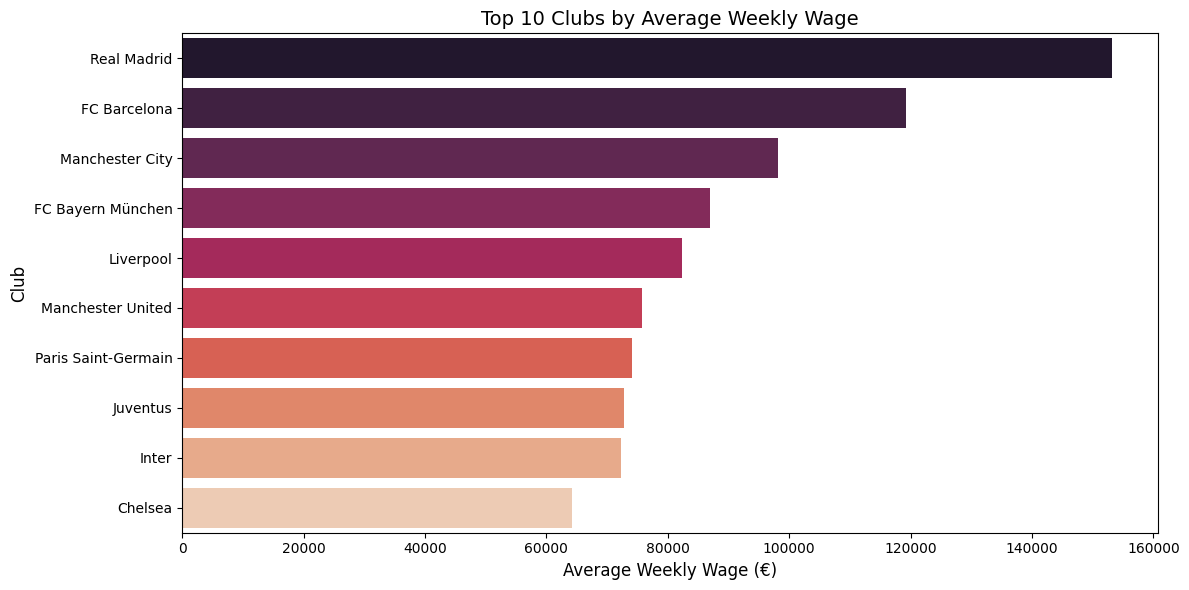

In [14]:
# Group and calculate
top_paying_clubs = (
    df.groupby('Club')['Wage_clean']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_paying_clubs.values, y=top_paying_clubs.index, palette='rocket')

plt.title("Top 10 Clubs by Average Weekly Wage", fontsize=14)
plt.xlabel("Average Weekly Wage (€)", fontsize=12)
plt.ylabel("Club", fontsize=12)

plt.tight_layout()
plt.show()

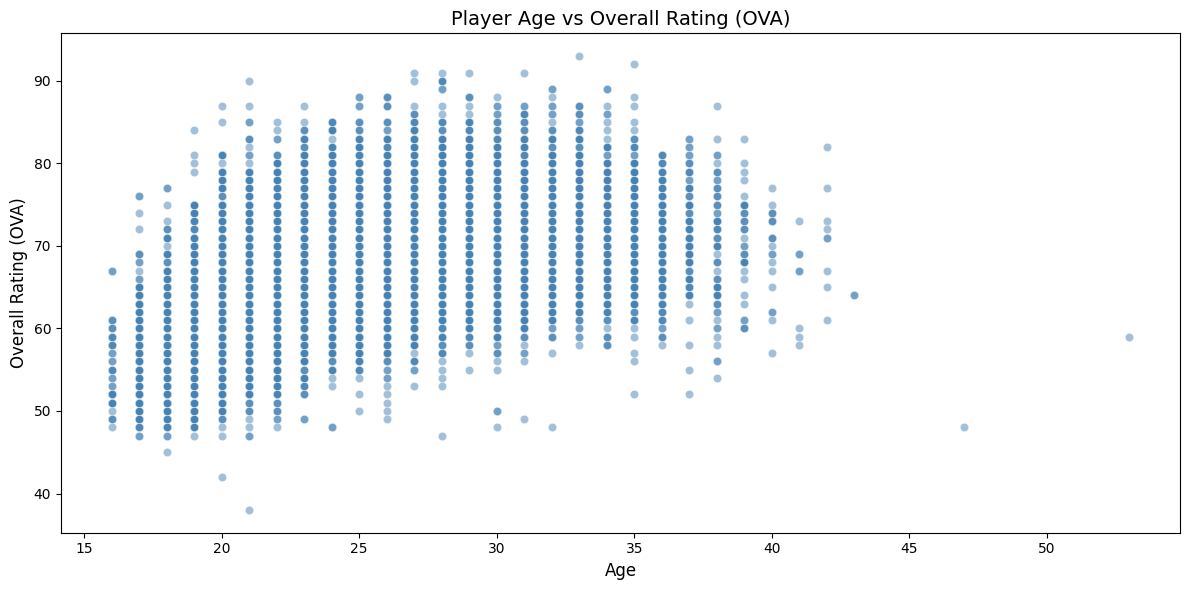

In [15]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    x='Age',
    y='OVA',
    data=df,
    alpha=0.5,           # transparency for overlapping points
    color='steelblue'
)

plt.title("Player Age vs Overall Rating (OVA)", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Overall Rating (OVA)", fontsize=12)

plt.tight_layout()
plt.show()

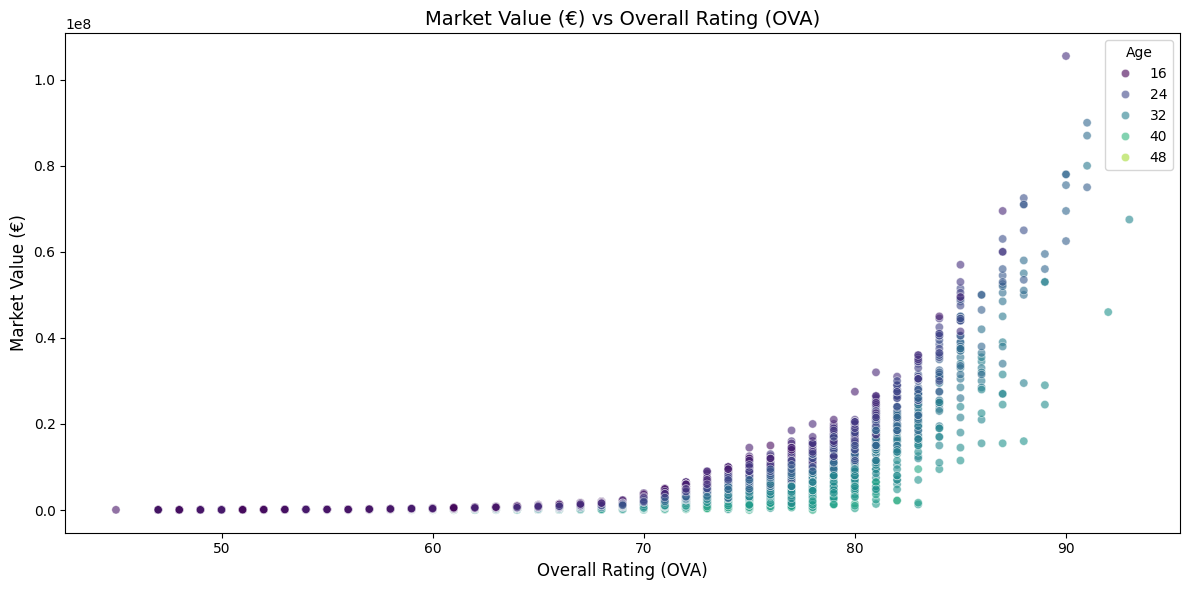

In [16]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    x='OVA',
    y='Value_clean',
    hue='Age',              # Adds 3rd dimension: color by Age
    palette='viridis',       # Color scheme
    alpha=0.6,               # Transparency to handle overlapping points
    data=df
)

plt.title("Market Value (€) vs Overall Rating (OVA)", fontsize=14)
plt.xlabel("Overall Rating (OVA)", fontsize=12)
plt.ylabel("Market Value (€)", fontsize=12)

# Optional: Format y-axis values into millions for clean presentation
# plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"€{x*1e-6:.0f}M"))

plt.tight_layout()
plt.show()

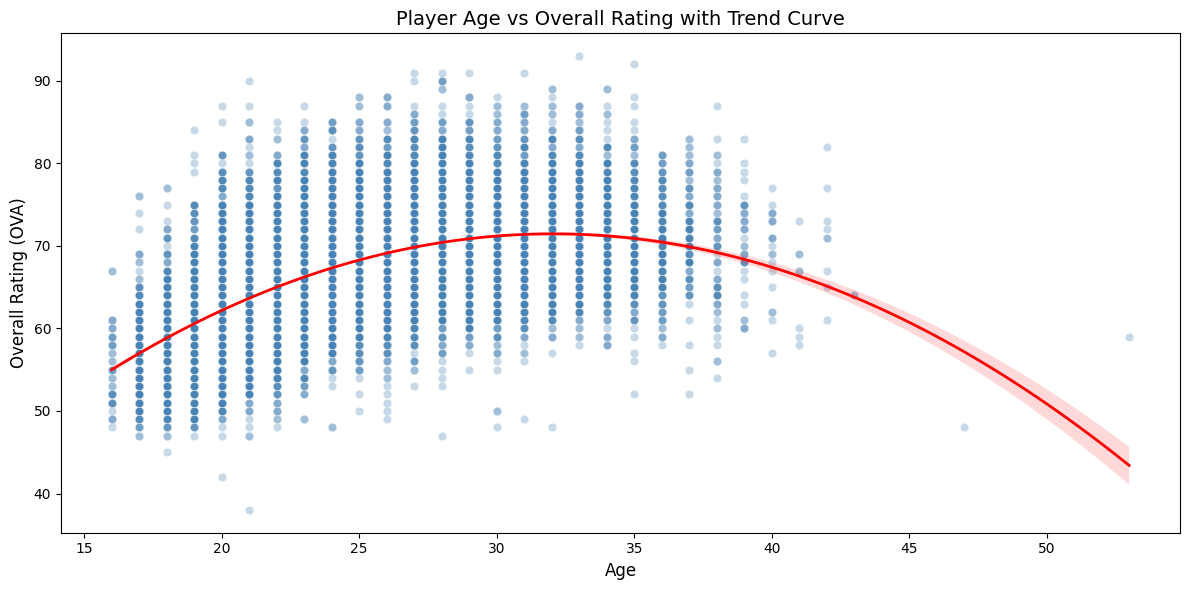

In [17]:
plt.figure(figsize=(12, 6))

# Scatter dots
sns.scatterplot(x='Age', y='OVA', data=df,
                alpha=0.3, color='steelblue')

# Add polynomial trend line (order=2 for U-curve)
sns.regplot(x='Age', y='OVA', data=df,
            scatter=False,           # do not re-plot the dots
            order=2,                 # quadratic curve
            color='red',
            line_kws={'linewidth': 2})

plt.title("Player Age vs Overall Rating with Trend Curve", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Overall Rating (OVA)", fontsize=12)

plt.tight_layout()
plt.show()